In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1. Pricing Floors

In [6]:
df = pd.read_excel('cap_curves_2025-06-30.xlsx', sheet_name='rate curves 2025-06-30')
df

,tenor,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
0,0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
1,0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
2,0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
3,1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
4,1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341
5,1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521
6,1.75,0.034942,0.034868,0.941054,0.030542,0.285885,0.336809
7,2.00,0.034453,0.034374,0.933835,0.030919,0.295615,0.328654
8,2.25,0.034000,0.033916,0.926827,0.030248,0.299596,0.312413
9,2.50,0.033750,0.033665,0.919605,0.031414,0.299589,0.296022


# Q 1.1)

In [7]:
# ----------------------------
# Parameters
# ----------------------------
N = 100
delta = 0.25
T = 3.0

# ----------------------------
# Extract required rows
# ----------------------------
row_T = df[df["tenor"] == 3.0].iloc[0]
row_T2 = df[df["tenor"] == 3.25].iloc[0]

K = row_T["swap rates"]          # Strike = 3Y swap rate
P0T = row_T["discounts"]         # P(0,3)
sigma = row_T["flat vols"]       # Black volatility
P0T2 = row_T2["discounts"]       # P(0,3.25)

# ----------------------------
# Forward rate (3Y -> 3.25Y)
# ----------------------------
F = (P0T / P0T2 - 1) / delta

# ----------------------------
# Black d1, d2
# ----------------------------
d1 = (np.log(F / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

# ----------------------------
# Floorlet price
# ----------------------------
price = N * delta * P0T * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

print("Forward rate:", F)
print("Floorlet price:", price)

Forward rate: 0.032816346984829714
Floorlet price: 0.1598731595669276


# Q 1.2)

In [8]:
# ----------------------------
# Parameters
# ----------------------------
N = 100
delta = 0.25
T_final = 3.0

# Strike = 3Y swap rate
K = df.loc[df["tenor"] == T_final, "swap rates"].iloc[0]

# Select floorlet maturities (exclude first quarter)
floorlet_tenors = df[(df["tenor"] > delta) & 
                     (df["tenor"] <= T_final)]["tenor"].values

total_price = 0

for T_i in floorlet_tenors:
    
    # Current and previous tenor rows
    row_T = df[df["tenor"] == T_i].iloc[0]
    row_prev = df[df["tenor"] == T_i - delta].iloc[0]
    
    P0T = row_T["discounts"]
    P0T_prev = row_prev["discounts"]
    sigma = row_T["flat vols"]
    
    # Forward rate
    F = (P0T_prev / P0T - 1) / delta
    
    # Black d1, d2
    d1 = (np.log(F / K) + 0.5 * sigma**2 * T_i) / (sigma * np.sqrt(T_i))
    d2 = d1 - sigma * np.sqrt(T_i)
    
    # Floorlet price
    floorlet_price = N * delta * P0T * (
        K * norm.cdf(-d2) - F * norm.cdf(-d1)
    )
    
    total_price += floorlet_price

print("Total floor price:", total_price)

Total floor price: 1.3178770350501736


# 2. Stripping Caps

# Q 2.1)

    Maturity  Cap Price
0       0.50   0.027441
1       0.75   0.070476
2       1.00   0.130579
3       1.25   0.211769
4       1.50   0.309123
5       1.75   0.419754
6       2.00   0.541474
7       2.25   0.669632
8       2.50   0.806306
9       2.75   0.950101
10      3.00   1.100554
11      3.25   1.254109
12      3.50   1.410934
13      3.75   1.577556
14      4.00   1.747528
15      4.25   1.919768
16      4.50   2.093558
17      4.75   2.275942
18      5.00   2.460421
19      5.25   2.647943
20      5.50   2.838025
21      5.75   3.030644
22      6.00   3.225541
23      6.25   3.424130
24      6.50   3.624287
25      6.75   3.825768
26      7.00   4.028487
27      7.25   4.232864
28      7.50   4.438603
29      7.75   4.645732
30      8.00   4.854254
31      8.25   5.062774
32      8.50   5.272540
33      8.75   5.483489
34      9.00   5.695531
35      9.25   5.907448
36      9.50   6.120167
37      9.75   6.333533
38     10.00   6.547365


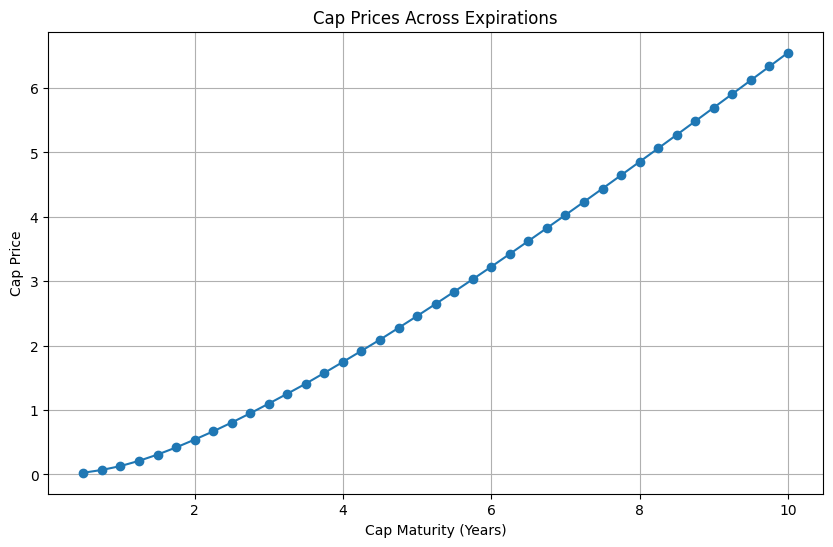

In [10]:
# for each cap maturities, use the flat vol to get the price of the cap across expirations
# ----------------------------
# Parameters
# ----------------------------
N = 100
delta = 0.25
T_max = df["tenor"].max()

# Store cap prices
cap_prices = []

# Cap maturities = unique tenors
cap_maturities = sorted(df["tenor"].unique())

# Remove first quarter (as specified)
cap_maturities = [T for T in cap_maturities if T > delta]

# ----------------------------
# Cap pricing across expirations
# ----------------------------
for T in cap_maturities:
    
    # Strike = swap rate at maturity
    K = df.loc[df["tenor"] == T, "swap rates"].iloc[0]
    
    cap_price_T = 0
    
    # Caplet payment dates up to T
    payment_tenors = [t for t in cap_maturities if t <= T]
    
    for T_i in payment_tenors:
        
        row_T = df[df["tenor"] == T_i].iloc[0]
        row_prev = df[df["tenor"] == T_i - delta].iloc[0]
        
        P0T = row_T["discounts"]
        P0T_prev = row_prev["discounts"]
        sigma = row_T["flat vols"]
        
        # Forward rate
        F = (P0T_prev / P0T - 1) / delta
        
        # Black d1, d2
        d1 = (np.log(F / K) + 0.5 * sigma**2 * T_i) / (sigma * np.sqrt(T_i))
        d2 = d1 - sigma * np.sqrt(T_i)
        
        caplet_price = N * delta * P0T * (
            F * norm.cdf(d1) - K * norm.cdf(d2)
        )
        
        cap_price_T += caplet_price
    
    cap_prices.append(cap_price_T)

# ----------------------------
# Report table
# ----------------------------
cap_df = pd.DataFrame({
    "Maturity": cap_maturities,
    "Cap Price": cap_prices
})

print(cap_df)

# ----------------------------
# Plot cap prices
# ----------------------------
plt.figure(figsize=(10,6))
plt.plot(cap_df["Maturity"], cap_df["Cap Price"], marker='o')
plt.xlabel("Cap Maturity (Years)")
plt.ylabel("Cap Price")
plt.title("Cap Prices Across Expirations")
plt.grid(True)
plt.show()

# Q 2.2)

    Maturity  Flat vols  Forward Volatility
0       0.50   0.156842            0.156842
1       0.75   0.180709            0.232011
2       1.00   0.204576            0.289514
3       1.25   0.242127            0.390800
4       1.50   0.268642            0.404832
5       1.75   0.285885            0.391051
6       2.00   0.295615            0.375417
7       2.25   0.299596            0.382937
8       2.50   0.299589            0.347583
9       2.75   0.297355            0.323924
10      3.00   0.294658            0.305246
11      3.25   0.292854            0.305139
12      3.50   0.291688            0.304634
13      3.75   0.290499            0.280644
14      4.00   0.288628            0.277962
15      4.25   0.285622            0.274619
16      4.50   0.281863            0.270496
17      4.75   0.277941            0.248036
18      5.00   0.274448            0.243502
19      5.25   0.271809            0.238524
20      5.50   0.269797            0.235760
21      5.75   0.268021         

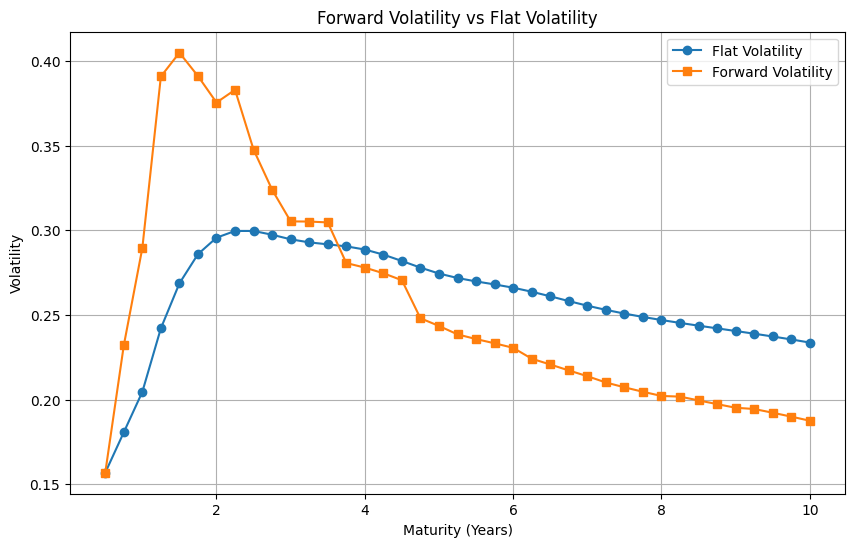

In [14]:
from scipy.optimize import brentq

# ----------------------------
# Parameters
# ----------------------------
N = 100
delta = 0.25

# Assume cap_df from previous step
cap_df = cap_df.sort_values("Maturity").reset_index(drop=True)

maturities = cap_df["Maturity"].values
cap_prices = cap_df["Cap Price"].values

# ----------------------------
# Step 1: Strip caplet prices
# ----------------------------
caplet_prices = []

for i in range(len(cap_prices)):
    
    if i == 0:
        caplet_prices.append(cap_prices[i])
    else:
        caplet_prices.append(cap_prices[i] - cap_prices[i-1])

cap_df["Caplet Price"] = caplet_prices

# ----------------------------
# Step 2: Strip forward volatility
# ----------------------------

forward_vols = []

def black_caplet_price(F, K, sigma, T, P0T):
    d1 = (np.log(F/K) + 0.5*sigma**2*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return N*delta*P0T*(F*norm.cdf(d1)-K*norm.cdf(d2))

for idx, row in cap_df.iterrows():

    T = row["Maturity"]
    market_price = row["Caplet Price"]

    # Strike = swap rate at maturity
    K = df.loc[df["tenor"] == T, "swap rates"].iloc[0]

    P0T = df.loc[df["tenor"] == T, "discounts"].iloc[0]

    # Forward rate
    row_prev = df[df["tenor"] == T-delta].iloc[0]
    row_T = df[df["tenor"] == T].iloc[0]

    F = (row_prev["discounts"]/row_T["discounts"] - 1)/delta

    # Solve for implied forward volatility
    def objective(sig):
        return black_caplet_price(F, K, sig, T, P0T) - market_price

    try:
        sigma_fwd = brentq(objective, 1e-6, 5)
    except:
        sigma_fwd = np.nan

    forward_vols.append(sigma_fwd)

cap_df["Forward Volatility"] = forward_vols
cap_df["Flat vols"] = [df.loc[df["tenor"] == T, "flat vols"].iloc[0] for T in cap_df["Maturity"]]

# ----------------------------
# Step 3: Report list
# ----------------------------
print(cap_df[["Maturity","Flat vols","Forward Volatility"]])

# ----------------------------
# Step 4: Plot flat vs forward volatility
# ----------------------------
plt.figure(figsize=(10,6))

plt.plot(cap_df["Maturity"], cap_df["Flat vols"],
         marker='o', label="Flat Volatility")

plt.plot(cap_df["Maturity"], cap_df["Forward Volatility"],
         marker='s', label="Forward Volatility")

plt.xlabel("Maturity (Years)")
plt.ylabel("Volatility")
plt.title("Forward Volatility vs Flat Volatility")
plt.legend()
plt.grid(True)

plt.show()